PARSING LOG FILES

Decentralized Approach:
  Parsed decentralized run 1: 61 samples
  Parsed decentralized run 10: 61 samples
  Parsed decentralized run 11: 61 samples
  Parsed decentralized run 12: 61 samples
  Parsed decentralized run 13: 61 samples
  Parsed decentralized run 14: 99 samples
  Parsed decentralized run 15: 99 samples
  Parsed decentralized run 16: 61 samples
  Parsed decentralized run 2: 61 samples
  Parsed decentralized run 3: 61 samples
  Parsed decentralized run 4: 61 samples
  Parsed decentralized run 5: 61 samples
  Parsed decentralized run 6: 61 samples
  Parsed decentralized run 7: 61 samples
  Parsed decentralized run 8: 61 samples
  Parsed decentralized run 9: 61 samples
Total decentralized runs: 16

Centralized Approach:
  Parsed centralized run 1: 61 samples
  Parsed centralized run 10: 61 samples
  Parsed centralized run 11: 61 samples
  Parsed centralized run 12: 61 samples
  Parsed centralized run 13: 61 samples
  Parsed centralized run 14: 61 samples
  P

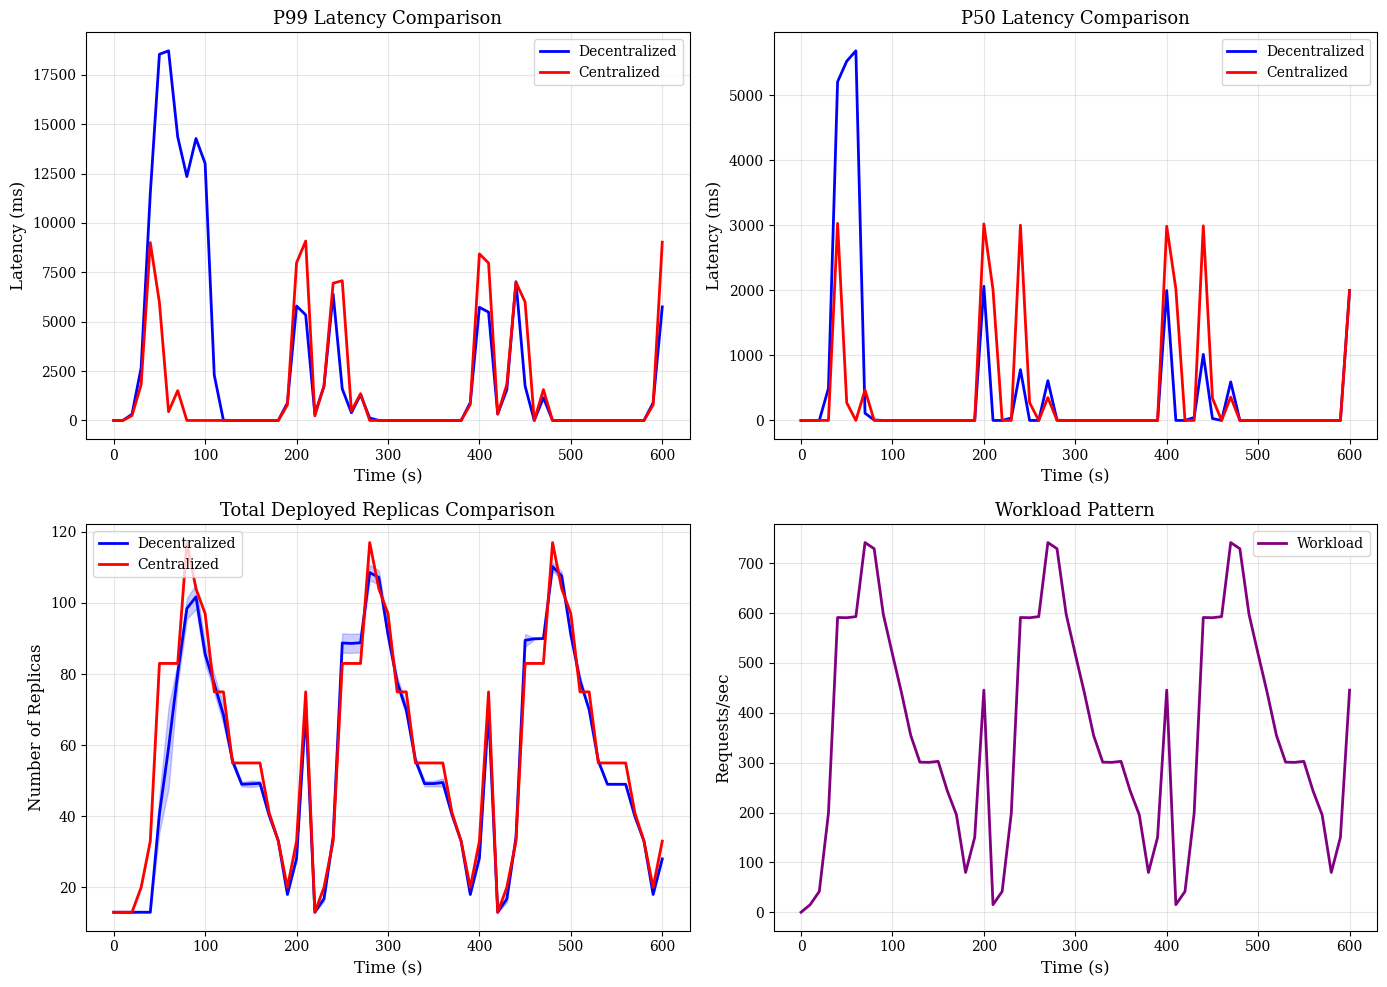

Combined latency figure saved to latency_comparison.pdf


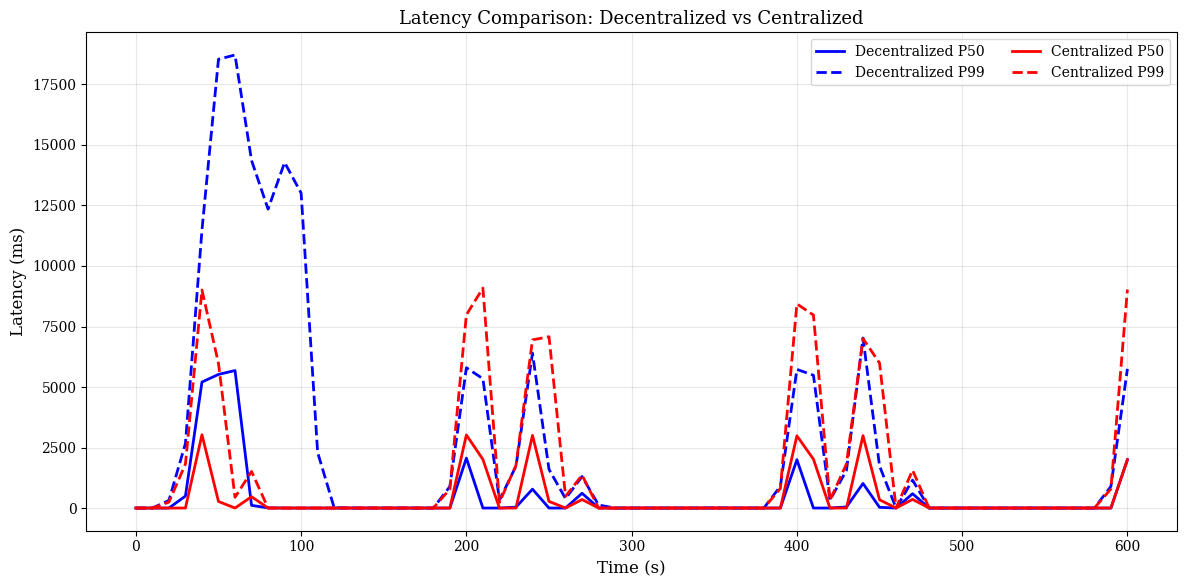


ANALYSIS COMPLETE!


In [10]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob

# Set publication-quality defaults
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['grid.alpha'] = 0.3

# ==================== PARSE GLOBAL_MONITOR ====================

def parse_global_monitor(log_file_path):
    """
    Parse GLOBAL_MONITOR lines from the log file.
    
    Args:
        log_file_path: Path to the log file
        
    Returns:
        pandas.DataFrame with parsed data
    """
    pattern = r'\[GLOBAL_MONITOR\] T=(\d+),p50=([\d.]+),p99=([\d.]+),req/s=([\d.]+),req_tot=([\d.]+),comp=([\d.]+),supp=([\d.]+),inst=([\d.]+),config=(.+)'
    
    records = []
    
    with open(log_file_path, 'r') as f:
        for line in f:
            if '[GLOBAL_MONITOR]' in line:
                match = re.search(pattern, line)
                if match:
                    t, p50, p99, req_s, req_tot, comp, supp, inst, config = match.groups()
                    
                    # Parse config list
                    config_list = eval(config.replace('list', ''))
                    
                    records.append({
                        'time': int(t),
                        'p50_latency': float(p50),
                        'p99_latency': float(p99),
                        'req_per_sec': float(req_s),
                        'req_total': float(req_tot),
                        'completed': float(comp),
                        'supported': float(supp),
                        'instances': float(inst),
                        'config': config_list,
                        'total_replicas': sum(config_list)
                    })
    
    return pd.DataFrame(records)


def parse_all_runs(file_pattern):
    """
    Parse all log files matching the pattern.
    
    Args:
        file_pattern: Glob pattern for log files (e.g., 'enron_decentralized_*.txt')
        
    Returns:
        dict mapping run_id to DataFrame
    """
    files = sorted(glob.glob(file_pattern))
    runs = {}
    
    # Extract approach name from pattern
    approach_match = re.search(r'enron_(\w+)_', file_pattern)
    approach_name = approach_match.group(1) if approach_match else "unknown"
    
    for file_path in files:
        # Extract run number from filename
        match = re.search(r'enron_\w+_(\d+)\.txt', file_path)
        if match:
            run_id = int(match.group(1))
            runs[run_id] = parse_global_monitor(file_path)
            print(f"  Parsed {approach_name} run {run_id}: {len(runs[run_id])} samples")
    
    return runs


# ==================== STATISTICAL ANALYSIS ====================

# ==================== STATISTICAL ANALYSIS ====================

def compute_aggregate_stats(runs):
    """
    Compute mean and std across multiple runs. Confidence intervals are removed for percentiles.
    
    Args:
        runs: dict mapping run_id to DataFrame
        
    Returns:
        DataFrame with aggregated statistics
    """
    # All runs have identical time vectors
    time_points = runs[list(runs.keys())[0]]['time'].values
    
    aggregated = {
        'time': time_points,
        'p50_mean': [],
        'p50_std': [],
        'p99_mean': [],
        'p99_std': [],
        'instances_mean': [],
        'instances_std': [],
        'replicas_mean': [],
        'replicas_std': [],
        'req_per_sec_mean': [],
        'req_per_sec_std': [],
    }
    
    for t in time_points:
        # Collect values at this time point across all runs
        p50_values = [runs[r].loc[runs[r]['time'] == t, 'p50_latency'].values[0] for r in runs]
        p99_values = [runs[r].loc[runs[r]['time'] == t, 'p99_latency'].values[0] for r in runs]
        inst_values = [runs[r].loc[runs[r]['time'] == t, 'instances'].values[0] for r in runs]
        rep_values = [runs[r].loc[runs[r]['time'] == t, 'total_replicas'].values[0] for r in runs]
        req_values = [runs[r].loc[runs[r]['time'] == t, 'req_per_sec'].values[0] for r in runs]
        
        # Percentile statistics: mean and std only
        aggregated['p50_mean'].append(np.mean(p50_values))
        aggregated['p50_std'].append(np.std(p50_values, ddof=1))
        aggregated['p99_mean'].append(np.mean(p99_values))
        aggregated['p99_std'].append(np.std(p99_values, ddof=1))
        
        # Instances and replicas: mean ± std
        aggregated['instances_mean'].append(np.mean(inst_values))
        aggregated['instances_std'].append(np.std(inst_values, ddof=1))
        aggregated['replicas_mean'].append(np.mean(rep_values))
        aggregated['replicas_std'].append(np.std(rep_values, ddof=1))
        
        # Request rate: mean ± std
        aggregated['req_per_sec_mean'].append(np.mean(req_values))
        aggregated['req_per_sec_std'].append(np.std(req_values, ddof=1))
    
    return pd.DataFrame(aggregated)



# ==================== Q1 JOURNAL QUALITY COMPARISON PLOTS ====================

# ==================== PLOTS ====================

def plot_comparison(agg_decentralized, agg_centralized, save_path=None):
    """
    Create publication-quality comparison plots between two approaches.
    CI shading removed for percentiles (p50/p99) since averaging percentiles is not statistically meaningful.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    time_dec = agg_decentralized['time']
    time_cen = agg_centralized['time']
    
    # Plot 1: P99 Latency Comparison (no CI)
    ax = axes[0, 0]
    ax.plot(time_dec, agg_decentralized['p99_mean'], 'b-', label='Decentralized', linewidth=2)
    ax.plot(time_cen, agg_centralized['p99_mean'], 'r-', label='Centralized', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('P99 Latency Comparison')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: P50 Latency Comparison (no CI)
    ax = axes[0, 1]
    ax.plot(time_dec, agg_decentralized['p50_mean'], 'b-', label='Decentralized', linewidth=2)
    ax.plot(time_cen, agg_centralized['p50_mean'], 'r-', label='Centralized', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('P50 Latency Comparison')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Total Replicas Comparison (mean ± std)
    ax = axes[1, 0]
    ax.plot(time_dec, agg_decentralized['replicas_mean'], 'b-', label='Decentralized', linewidth=2)
    ax.fill_between(time_dec,
                    agg_decentralized['replicas_mean'] - agg_decentralized['replicas_std'],
                    agg_decentralized['replicas_mean'] + agg_decentralized['replicas_std'],
                    alpha=0.2, color='b')
    ax.plot(time_cen, agg_centralized['replicas_mean'], 'r-', label='Centralized', linewidth=2)
    ax.fill_between(time_cen,
                    agg_centralized['replicas_mean'] - agg_centralized['replicas_std'],
                    agg_centralized['replicas_mean'] + agg_centralized['replicas_std'],
                    alpha=0.2, color='r')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Number of Replicas')
    ax.set_title('Total Deployed Replicas Comparison')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Workload Pattern (should be same for both)
    ax = axes[1, 1]
    ax.plot(time_dec, agg_decentralized['req_per_sec_mean'], 'purple', label='Workload', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Requests/sec')
    ax.set_title('Workload Pattern')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Comparison figure saved to {save_path}")
    
    plt.show()



def plot_combined_latency_comparison(agg_decentralized, agg_centralized, save_path=None):
    """
    Plot P50 and P99 latency without CI shading for percentiles.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    time_dec = agg_decentralized['time']
    time_cen = agg_centralized['time']
    
    # Decentralized
    ax.plot(time_dec, agg_decentralized['p50_mean'], 'b-', label='Decentralized P50', linewidth=2)
    ax.plot(time_dec, agg_decentralized['p99_mean'], 'b--', label='Decentralized P99', linewidth=2)
    
    # Centralized
    ax.plot(time_cen, agg_centralized['p50_mean'], 'r-', label='Centralized P50', linewidth=2)
    ax.plot(time_cen, agg_centralized['p99_mean'], 'r--', label='Centralized P99', linewidth=2)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Comparison: Decentralized vs Centralized')
    ax.legend(loc='best', ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Combined latency figure saved to {save_path}")
    
    plt.show()

def print_comparison_table(runs_decentralized, runs_centralized):
    """
    Print a comparison table suitable for inclusion in papers.
    
    Args:
        runs_decentralized: dict of decentralized runs
        runs_centralized: dict of centralized runs
    """
    print("\n" + "="*100)
    print("COMPARISON: DECENTRALIZED vs CENTRALIZED")
    print("="*100)
    
    # Compute aggregate metrics for each approach
    metrics_dec = []
    for run_id, df in runs_decentralized.items():
        metrics_dec.append({
            'Avg P50 (ms)': df['p50_latency'].mean(),
            'Avg P99 (ms)': df['p99_latency'].mean(),
            'Max P99 (ms)': df['p99_latency'].max(),
            'Avg Instances': df['instances'].mean(),
            'Max Instances': df['instances'].max(),
            'Avg Replicas': df['total_replicas'].mean(),
            'Max Replicas': df['total_replicas'].max(),
        })
    
    metrics_cen = []
    for run_id, df in runs_centralized.items():
        metrics_cen.append({
            'Avg P50 (ms)': df['p50_latency'].mean(),
            'Avg P99 (ms)': df['p99_latency'].mean(),
            'Max P99 (ms)': df['p99_latency'].max(),
            'Avg Instances': df['instances'].mean(),
            'Max Instances': df['instances'].max(),
            'Avg Replicas': df['total_replicas'].mean(),
            'Max Replicas': df['total_replicas'].max(),
        })
    
    df_dec = pd.DataFrame(metrics_dec)
    df_cen = pd.DataFrame(metrics_cen)
    
    print("\nAggregate Statistics (Mean ± Std):")
    print("-"*100)
    print(f"{'Metric':<25} {'Decentralized':<30} {'Centralized':<30}")
    print("-"*100)
    
    for col in df_dec.columns:
        mean_dec = df_dec[col].mean()
        std_dec = df_dec[col].std()
        mean_cen = df_cen[col].mean()
        std_cen = df_cen[col].std()
        
        # Calculate improvement percentage
        if mean_cen != 0:
            improvement = ((mean_cen - mean_dec) / mean_cen) * 100
            sign = "↓" if improvement > 0 else "↑"
            print(f"{col:<25} {mean_dec:8.2f} ± {std_dec:6.2f}          {mean_cen:8.2f} ± {std_cen:6.2f}          ({sign} {abs(improvement):.1f}%)")
        else:
            print(f"{col:<25} {mean_dec:8.2f} ± {std_dec:6.2f}          {mean_cen:8.2f} ± {std_cen:6.2f}")
    
    print("="*100 + "\n")


# ==================== MAIN EXECUTION ====================

# Parse all runs for both approaches
print("="*80)
print("PARSING LOG FILES")
print("="*80)

print("\nDecentralized Approach:")
runs_decentralized = parse_all_runs('performance/enron_decentralized_*.txt')
print(f"Total decentralized runs: {len(runs_decentralized)}")

print("\nCentralized Approach:")
runs_centralized = parse_all_runs('performance/enron_centralized_*.txt')
print(f"Total centralized runs: {len(runs_centralized)}")

# Compute aggregate statistics
print("\n" + "="*80)
print("COMPUTING AGGREGATE STATISTICS")
print("="*80)
agg_decentralized = compute_aggregate_stats(runs_decentralized)
agg_centralized = compute_aggregate_stats(runs_centralized)
print("Done.")

# Print comparison table
print_comparison_table(runs_decentralized, runs_centralized)

# Create comparison plots
print("="*80)
print("GENERATING COMPARISON PLOTS")
print("="*80)
plot_comparison(agg_decentralized, agg_centralized, save_path='approach_comparison.pdf')
plot_combined_latency_comparison(agg_decentralized, agg_centralized, save_path='latency_comparison.pdf')

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)